In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, spearmanr
from sklearn.preprocessing import StandardScaler
import os

# Directories
PROCESSED_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\data\processed"
OUTPUT_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
LOG_FILE = os.path.join(OUTPUT_DIR, "Descriptive_Analytics_Log.txt")

os.makedirs(FIGURES_DIR, exist_ok=True)

# Clear log file
with open(LOG_FILE, "w", encoding="utf-8") as f:
    f.write("=== THESIS DESCRIPTIVE ANALYTICS LOG ===\n\n")

def log_result(text):
    print(text)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(text + "\n")

# Load V2 datasets
df_orig = pd.read_csv(os.path.join(PROCESSED_DIR, "01_Original_12k_V2_scored.csv"))
df_dist_a = pd.read_csv(os.path.join(PROCESSED_DIR, "02_Distractor_A_Swapped_12k_V2_scored.csv"))
df_dist_b = pd.read_csv(os.path.join(PROCESSED_DIR, "03_Distractor_B_Shuffled_12k_V2_scored.csv"))

# Drop missing values
df_orig = df_orig.dropna(subset=['codebert_score', 'adak_index']).copy()
df_dist_a = df_dist_a.dropna(subset=['codebert_score', 'adak_index']).copy()
df_dist_b = df_dist_b.dropna(subset=['codebert_score', 'adak_index']).copy()

# Ensure word and token counts exist for all DataFrames
token_col = 'code_token_length' if 'code_token_length' in df_orig.columns else 'token_count'
for df in[df_orig, df_dist_a, df_dist_b]:
    df['comment_word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
    df['code_token_length'] = df[token_col]

# Styling for academic presentation
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12})

log_result("Setup Complete. Data loaded and preprocessed.")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Setup Complete. Data loaded and preprocessed.


In [2]:
log_result(f"\n{'='*50}\n1. EXPERIMENTAL CLASS VALIDATION\n{'='*50}")

# Print sample sizes
log_result(f"Sample Size (Class 1 - Original): {len(df_orig)}")
log_result(f"Sample Size (Class 0 - Swapped):  {len(df_dist_a)}")
log_result(f"Sample Size (Class 2 - Shuffled): {len(df_dist_b)}\n")

log_result(f"{'='*50}\n2. DEEP STATISTICAL PROFILING\n{'='*50}")

variables =['adak_index', 'codebert_score', 'mcv', 'sfv', 'code_token_length', 'comment_word_count']

def get_detailed_stats(dataframe, columns):
    summary = dataframe[columns].describe().T
    summary['mode'] = dataframe[columns].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    summary['skewness'] = dataframe[columns].skew()
    summary['kurtosis'] = dataframe[columns].apply(kurtosis)
    return summary.round(4)

# Global Stats
global_stats = get_detailed_stats(df_orig, variables)
log_result("GLOBAL STATISTICS (All Languages Combined):")
log_result(global_stats.to_string())
global_stats.to_csv(os.path.join(OUTPUT_DIR, "Table_1_Global_Detailed_Stats.csv"))

# Per-Language Stats
lang_stats_list =[]
for lang in df_orig['language'].unique():
    lang_df = df_orig[df_orig['language'] == lang]
    l_stats = get_detailed_stats(lang_df, variables)
    l_stats.insert(0, 'language', lang) 
    lang_stats_list.append(l_stats)

master_lang_stats = pd.concat(lang_stats_list)
master_lang_stats.to_csv(os.path.join(OUTPUT_DIR, "Table_2_Language_Detailed_Stats.csv"))
log_result(f"\nDetailed per-language statistics saved to outputs folder.")


1. EXPERIMENTAL CLASS VALIDATION
Sample Size (Class 1 - Original): 12000
Sample Size (Class 0 - Swapped):  12000
Sample Size (Class 2 - Shuffled): 12000

2. DEEP STATISTICAL PROFILING
GLOBAL STATISTICS (All Languages Combined):
                      count     mean      std      min      25%      50%       75%        max     mode  skewness  kurtosis
adak_index          12000.0 -73.5733  48.6447 -99.4624 -93.8697 -87.3016  -69.8113  1605.0505 -88.4058   11.9735  285.1411
codebert_score      12000.0   0.9597   0.0266   0.8239   0.9477   0.9678    0.9779     0.9996   0.9756   -1.3566    1.8910
mcv                 12000.0   3.5603   5.5567   0.8000   0.8000   2.4000    4.0000   195.2000   0.8000   10.9372  249.6134
sfv                 12000.0  22.3506  20.9026   1.5000   9.3000  15.0000   27.3000   151.8000   6.9000    2.4506    7.3131
code_token_length   12000.0  97.3067  84.1026  16.0000  42.0000  67.0000  119.0000   512.0000  25.0000    2.1062    4.8299
comment_word_count  12000.0  29.5


3. ML DATA NORMALIZATION ANALYSIS


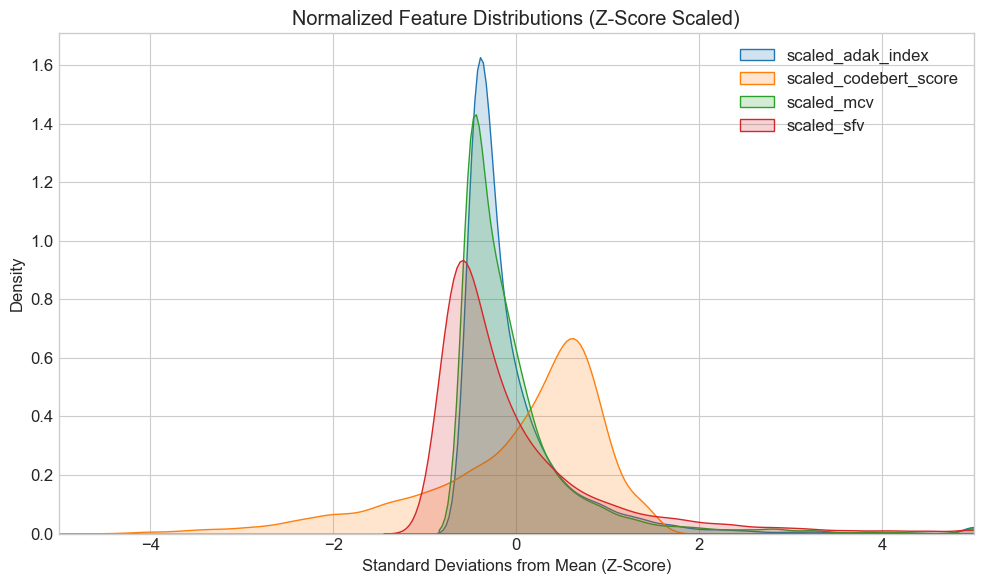

Normalization complete. Distribution graph saved to demonstrate feature alignment for ML.


In [3]:
log_result(f"\n{'='*50}\n3. ML DATA NORMALIZATION ANALYSIS\n{'='*50}")

scaler = StandardScaler()
features_to_scale =['adak_index', 'codebert_score', 'mcv', 'sfv']

# Apply standard scaler (Z-score normalization)
scaled_data = scaler.fit_transform(df_orig[features_to_scale])
df_scaled = pd.DataFrame(scaled_data, columns=[f"scaled_{f}" for f in features_to_scale])

plt.figure(figsize=(10, 6))
for col in df_scaled.columns:
    # We clip the visualization between -5 and 5 standard deviations to ignore extreme outliers visually
    sns.kdeplot(df_scaled[col].clip(-5, 5), label=col, fill=True, alpha=0.2)

plt.title('Normalized Feature Distributions (Z-Score Scaled)')
plt.xlabel('Standard Deviations from Mean (Z-Score)')
plt.ylabel('Density')
plt.xlim(-5, 5)
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "EDA_Normalized_Distributions.png"), dpi=300, bbox_inches='tight')
plt.show()

log_result("Normalization complete. Distribution graph saved to demonstrate feature alignment for ML.")


4. CODE COMPLEXITY (SFV) DISTRIBUTION ANALYSIS


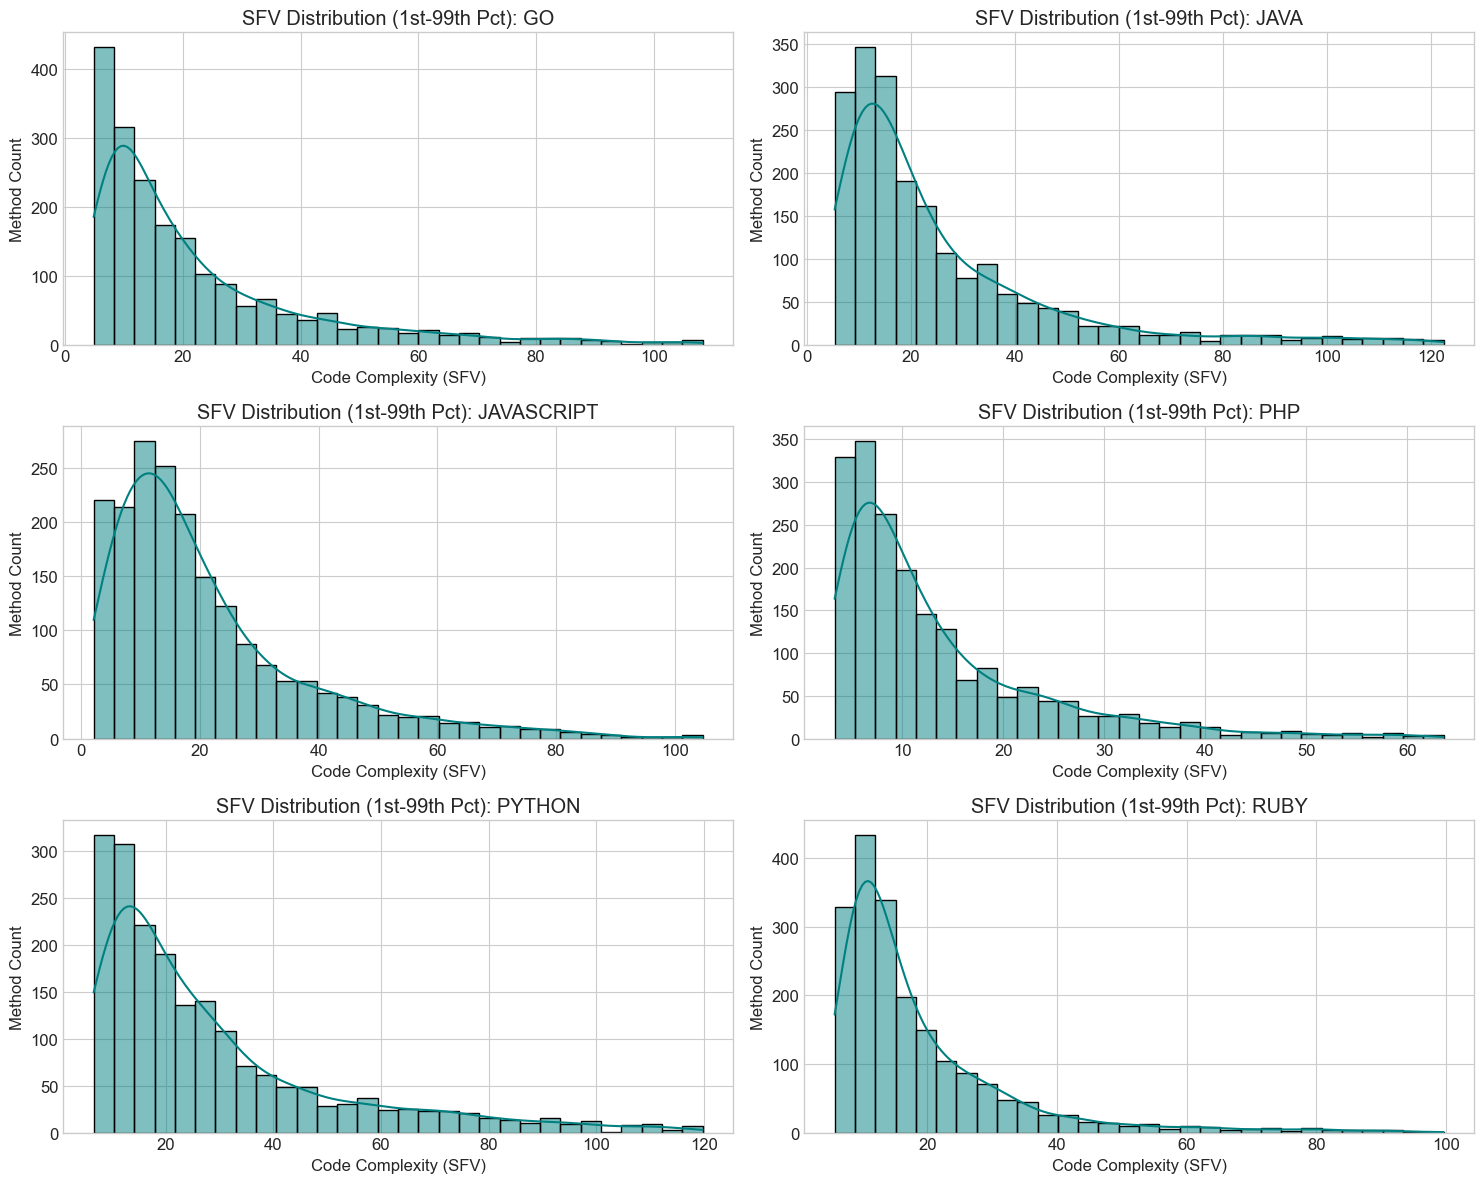

SFV distribution histograms generated successfully with robust percentile clipping.


In [4]:
log_result(f"\n{'='*50}\n4. CODE COMPLEXITY (SFV) DISTRIBUTION ANALYSIS\n{'='*50}")

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, lang in enumerate(df_orig['language'].unique()):
    lang_data = df_orig[df_orig['language'] == lang]
    
    # Percentile Clipping (1st to 99th) to remove extreme parser artifacts (e.g., PHP HTML blocks)
    lower_limit = lang_data['sfv'].quantile(0.01)
    upper_limit = lang_data['sfv'].quantile(0.99)
    
    clean_plot_data = lang_data[(lang_data['sfv'] >= lower_limit) & (lang_data['sfv'] <= upper_limit)]

    sns.histplot(clean_plot_data['sfv'], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'SFV Distribution (1st-99th Pct): {lang.upper()}')
    axes[i].set_xlabel('Code Complexity (SFV)')
    axes[i].set_ylabel('Method Count')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "EDA_SFV_Per_Language_Fixed.png"), dpi=300, bbox_inches='tight')
plt.show()

log_result("SFV distribution histograms generated successfully with robust percentile clipping.")


5. VARIABLE RELATIONSHIP CORRELATIONS
Spearman Correlation (SFV vs MCV): 0.0559 (p-value: 9.0619e-10)
Spearman Correlation (SFV vs CodeBERT): -0.2207 (p-value: 2.5039e-132)


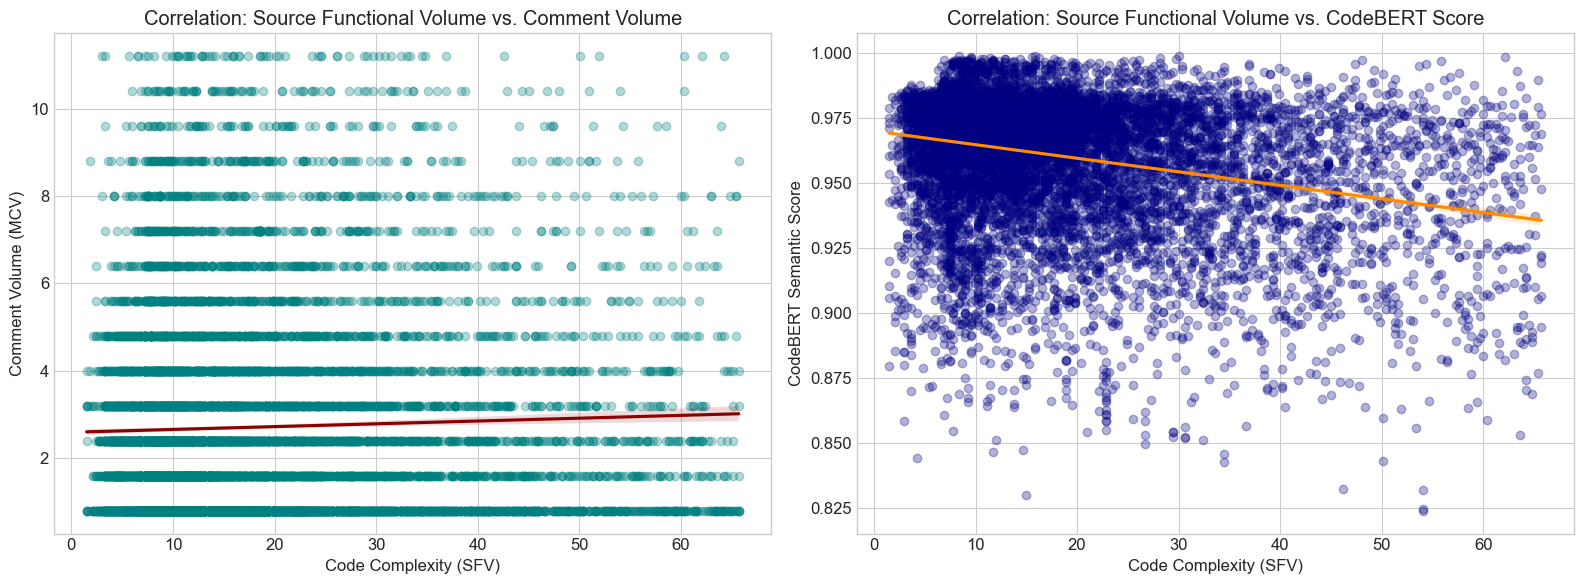

In [5]:
log_result(f"\n{'='*50}\n5. VARIABLE RELATIONSHIP CORRELATIONS\n{'='*50}")

# 1. SFV vs MCV (Testing the Adak assumption)
spearman_mcv, p_mcv = spearmanr(df_orig['sfv'], df_orig['mcv'])
log_result(f"Spearman Correlation (SFV vs MCV): {spearman_mcv:.4f} (p-value: {p_mcv:.4e})")

# 2. SFV vs CodeBERT (Testing AI limitation on long code)
spearman_cb, p_cb = spearmanr(df_orig['sfv'], df_orig['codebert_score'])
log_result(f"Spearman Correlation (SFV vs CodeBERT): {spearman_cb:.4f} (p-value: {p_cb:.4e})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cap outliers for visualization purposes
sfv_cap = df_orig['sfv'].quantile(0.95)
mcv_cap = df_orig['mcv'].quantile(0.95)
filtered_df = df_orig[(df_orig['sfv'] <= sfv_cap) & (df_orig['mcv'] <= mcv_cap)]

# Plot A: SFV vs MCV
sns.regplot(data=filtered_df, x='sfv', y='mcv', ax=axes[0],
            scatter_kws={'alpha':0.3, 'color': 'teal'}, line_kws={'color': 'darkred'})
axes[0].set_title('Correlation: Source Functional Volume vs. Comment Volume')
axes[0].set_xlabel('Code Complexity (SFV)')
axes[0].set_ylabel('Comment Volume (MCV)')

# Plot B: SFV vs CodeBERT
sns.regplot(data=filtered_df, x='sfv', y='codebert_score', ax=axes[1],
            scatter_kws={'alpha':0.3, 'color': 'navy'}, line_kws={'color': 'darkorange'})
axes[1].set_title('Correlation: Source Functional Volume vs. CodeBERT Score')
axes[1].set_xlabel('Code Complexity (SFV)')
axes[1].set_ylabel('CodeBERT Semantic Score')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "EDA_Variable_Correlations.png"), dpi=300, bbox_inches='tight')
plt.show()


6. SEMANTIC GROUND TRUTH VALIDATION
Mean CodeBERT Score (Valid):    0.9597
Mean CodeBERT Score (Swapped):  0.9549
Mean CodeBERT Score (Shuffled): 0.9530


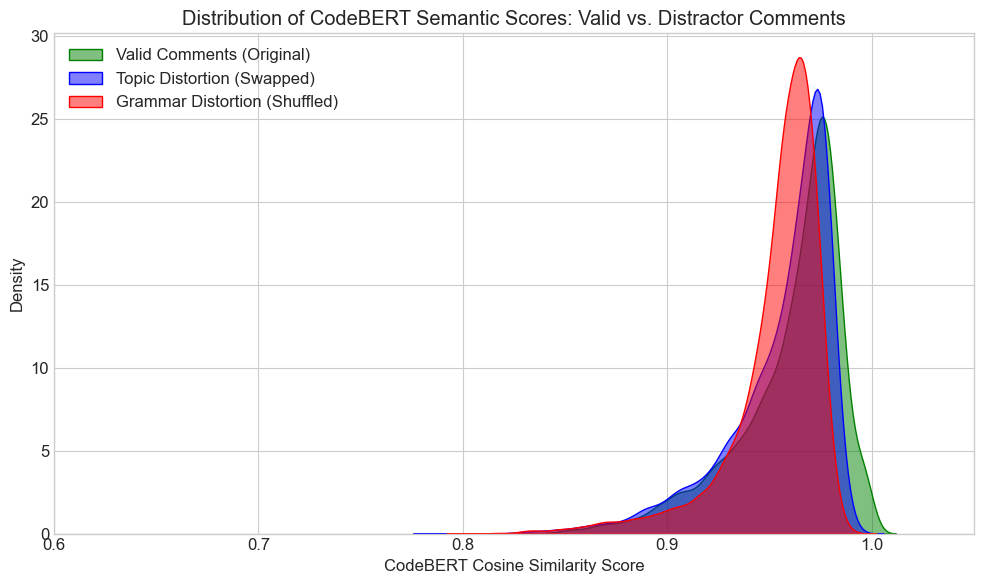


Descriptive Analytics successfully completed.


In [6]:
log_result(f"\n{'='*50}\n6. SEMANTIC GROUND TRUTH VALIDATION\n{'='*50}")

# Log the mean CodeBERT scores
log_result(f"Mean CodeBERT Score (Valid):    {df_orig['codebert_score'].mean():.4f}")
log_result(f"Mean CodeBERT Score (Swapped):  {df_dist_a['codebert_score'].mean():.4f}")
log_result(f"Mean CodeBERT Score (Shuffled): {df_dist_b['codebert_score'].mean():.4f}")

plt.figure(figsize=(10, 6))

# Plot Density Curves
sns.kdeplot(df_orig['codebert_score'], fill=True, color='green', label='Valid Comments (Original)', alpha=0.5)
sns.kdeplot(df_dist_a['codebert_score'], fill=True, color='blue', label='Topic Distortion (Swapped)', alpha=0.5)
sns.kdeplot(df_dist_b['codebert_score'], fill=True, color='red', label='Grammar Distortion (Shuffled)', alpha=0.5)

plt.title('Distribution of CodeBERT Semantic Scores: Valid vs. Distractor Comments')
plt.xlabel('CodeBERT Cosine Similarity Score')
plt.ylabel('Density')
plt.legend(loc='upper left')

# Limit X-axis to where the data naturally clusters due to Embedding Anisotropy
plt.xlim(0.6, 1.05) 

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "EDA_CodeBERT_Distributions.png"), dpi=300, bbox_inches='tight')
plt.show()

log_result("\nDescriptive Analytics successfully completed.")